<a href="https://colab.research.google.com/github/Cybsty/Cisco-packet-tracer-labs/blob/main/PUBLIC%20-%20Unimodal_Visual_Deception_Detection_on_the_Real_Life_Trial_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Unimodal Visual Deception Detection on the Real-Life Trial Dataset

Author: Nasra Nur

E : nasra.b.nur@gmail.com

L : www.linkedin.com/in/nasranur

G : https://github.com/Cybsty



####**High‑Level Description**

###  Introduction

This notebook presents a unimodal visual deception detection pipeline developed using the **Real-Life Trial dataset**. The analysis is restricted to visual information so that the predictive value of structured behavioral features can be examined independently, without relying on audio, text, or multimodal fusion. In doing so, the notebook establishes a focused baseline for assessing how effectively visual cues alone can support deception detection in a realistic trial setting.

The workflow follows a standard end-to-end machine learning process. It begins with dataset preparation and clip-level labeling, then aligns annotation-based visual features with the corresponding video samples to construct a structured feature table. The resulting feature matrix is preprocessed, split into training and test sets, and used to train a compact **PyTorch multilayer perceptron** for binary classification. Model performance is then evaluated on held-out data using accuracy, a classification report, and a confusion matrix.

The central question guiding this work is whether **visual behavioral features alone can meaningfully distinguish truthful from deceptive trial clips**. By focusing on a visual-only setting, the notebook aims to measure the value of this modality in isolation, identify its practical limitations, and provide a clear baseline for future comparison with stronger visual architectures or multimodal deception detection approaches.

## Environment Setup

This section loads the libraries used for data preparation, visualization, preprocessing, and neural network training.

In [19]:
import random
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

In [20]:
def set_seed(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### Data Preparation

This section extracts the dataset, assembles a clip-level manifest, and summarizes the class distribution.

In [21]:
from google.colab import drive

drive.mount("/content/drive")

zip_src_path = Path("/content/drive/MyDrive/RealLifeDeceptionDetection.2016.zip")
work_root = Path("/content/rlt_unimodal")
data_root = work_root / "data"
data_root.mkdir(parents=True, exist_ok=True)

dataset_root = data_root / "Real-life_Deception_Detection_2016"

if not dataset_root.exists():
    with zipfile.ZipFile(zip_src_path, "r") as zip_ref:
        zip_ref.extractall(data_root)

clips_root = dataset_root / "Clips"
label_map = {"Truthful": 0, "Deceptive": 1}

manifest_rows = []
for label_name, label_value in label_map.items():
    class_root = clips_root / label_name
    video_paths = sorted(class_root.glob("*.mp4"))

    for video_path in video_paths:
        manifest_rows.append(
            {
                "video_id": video_path.stem,
                "video_name": video_path.name,
                "video_path": str(video_path),
                "label": label_value,
                "label_name": label_name.lower()
            }
        )

df = pd.DataFrame(manifest_rows).sort_values("video_id").reset_index(drop=True)

print(df.head())
print(df["label_name"].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
        video_id         video_name  \
0  trial_lie_001  trial_lie_001.mp4   
1  trial_lie_002  trial_lie_002.mp4   
2  trial_lie_003  trial_lie_003.mp4   
3  trial_lie_004  trial_lie_004.mp4   
4  trial_lie_005  trial_lie_005.mp4   

                                          video_path  label label_name  
0  /content/rlt_unimodal/data/Real-life_Deception...      1  deceptive  
1  /content/rlt_unimodal/data/Real-life_Deception...      1  deceptive  
2  /content/rlt_unimodal/data/Real-life_Deception...      1  deceptive  
3  /content/rlt_unimodal/data/Real-life_Deception...      1  deceptive  
4  /content/rlt_unimodal/data/Real-life_Deception...      1  deceptive  
label_name
deceptive    61
truthful     60
Name: count, dtype: int64


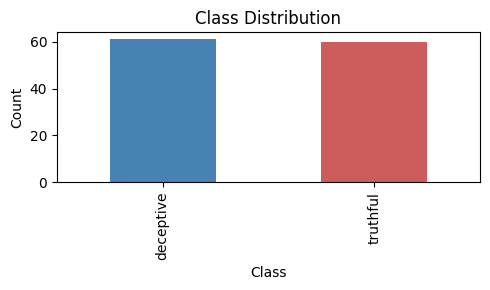

In [22]:
plt.figure(figsize=(5, 3))
df["label_name"].value_counts().sort_index().plot(kind="bar", color=["steelblue", "indianred"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Annotation-Based Visual Features

This section loads the clip-level behavioral annotations and aligns them with the video manifest to form the unimodal visual feature table.

In [23]:
annotation_path = dataset_root / "Annotation" / "All_Gestures_Deceptive and Truthful.csv"
ann_df = pd.read_csv(annotation_path)

ann_df.columns = [str(col_name).strip() for col_name in ann_df.columns]
ann_df["video_name"] = ann_df["id"].astype(str).str.strip()
ann_df["video_id"] = ann_df["video_name"].str.replace(".mp4", "", regex=False)

print(annotation_path)
print(ann_df.head())
print(ann_df.shape)

/content/rlt_unimodal/data/Real-life_Deception_Detection_2016/Annotation/All_Gestures_Deceptive and Truthful.csv
                  id  OtherGestures  Smile  Laugh  Scowl  \
0  trial_lie_001.mp4              1      0      0      0   
1  trial_lie_002.mp4              1      0      0      0   
2  trial_lie_003.mp4              1      0      0      0   
3  trial_lie_004.mp4              1      0      0      0   
4  trial_lie_005.mp4              1      0      0      0   

   otherEyebrowMovement  Frown  Raise  OtherEyeMovements  Close-R  ...  \
0                     1      0      0                  1        0  ...   
1                     0      1      0                  1        0  ...   
2                     0      1      0                  0        1  ...   
3                     1      0      0                  1        0  ...   
4                     0      1      0                  1        0  ...   

   singleHand  bothHands  otherHandM  complexHandM  sidewaysHand  downHands  \
0 

In [24]:
merged_df = df.merge(ann_df, on=["video_id", "video_name"], how="inner")
merged_df = merged_df.copy()

print(merged_df.head())
print(merged_df.shape)

        video_id         video_name  \
0  trial_lie_001  trial_lie_001.mp4   
1  trial_lie_002  trial_lie_002.mp4   
2  trial_lie_003  trial_lie_003.mp4   
3  trial_lie_004  trial_lie_004.mp4   
4  trial_lie_005  trial_lie_005.mp4   

                                          video_path  label label_name  \
0  /content/rlt_unimodal/data/Real-life_Deception...      1  deceptive   
1  /content/rlt_unimodal/data/Real-life_Deception...      1  deceptive   
2  /content/rlt_unimodal/data/Real-life_Deception...      1  deceptive   
3  /content/rlt_unimodal/data/Real-life_Deception...      1  deceptive   
4  /content/rlt_unimodal/data/Real-life_Deception...      1  deceptive   

                  id  OtherGestures  Smile  Laugh  Scowl  ...  forwardHead  \
0  trial_lie_001.mp4              1      0      0      0  ...            0   
1  trial_lie_002.mp4              1      0      0      0  ...            0   
2  trial_lie_003.mp4              1      0      0      0  ...            0   
3  trial

### Feature extraction environment

This section pins the facial landmark dependency to a stable version before extracting per-video features.

In [25]:
%pip uninstall -q -y mediapipe
%pip install -q mediapipe==0.10.14

In [26]:
import mediapipe as mp
import numpy as np

print(mp.__version__)
print(hasattr(mp, "solutions"))

mp_face_mesh = mp.solutions.face_mesh
print(mp_face_mesh)

0.10.14
True
<module 'mediapipe.python.solutions.face_mesh' from '/usr/local/lib/python3.12/dist-packages/mediapipe/python/solutions/face_mesh.py'>


# Feature Construction

This section selects the numeric annotation variables used as model inputs and assembles the feature matrix and target vector.

In [27]:
exclude_cols = {"id", "video_id", "video_name", "video_path", "label", "label_name", "class"}
numeric_feature_cols = []

for col_name in merged_df.columns:
    if col_name in exclude_cols:
        continue
    if pd.api.types.is_numeric_dtype(merged_df[col_name]):
        numeric_feature_cols.append(col_name)

model_df = merged_df[["video_id", "video_name", "label"] + numeric_feature_cols].copy()
model_df[numeric_feature_cols] = model_df[numeric_feature_cols].apply(pd.to_numeric, errors="coerce")
model_df[numeric_feature_cols] = model_df[numeric_feature_cols].fillna(0.0)

X = model_df[numeric_feature_cols].to_numpy(dtype=np.float32)
y = model_df["label"].to_numpy(dtype=np.int64)

print(model_df.head())
print(X.shape)
print(y.shape)

        video_id         video_name  label  OtherGestures  Smile  Laugh  \
0  trial_lie_001  trial_lie_001.mp4      1              1      0      0   
1  trial_lie_002  trial_lie_002.mp4      1              1      0      0   
2  trial_lie_003  trial_lie_003.mp4      1              1      0      0   
3  trial_lie_004  trial_lie_004.mp4      1              1      0      0   
4  trial_lie_005  trial_lie_005.mp4      1              1      0      0   

   Scowl  otherEyebrowMovement  Frown  Raise  ...  waggle  forwardHead  \
0      0                     1      0      0  ...       0            0   
1      0                     0      1      0  ...       0            0   
2      0                     0      1      0  ...       0            0   
3      0                     1      0      0  ...       0            0   
4      0                     0      1      0  ...       0            0   

   downRHead  singleHand  bothHands  otherHandM  complexHandM  sidewaysHand  \
0          0           0 

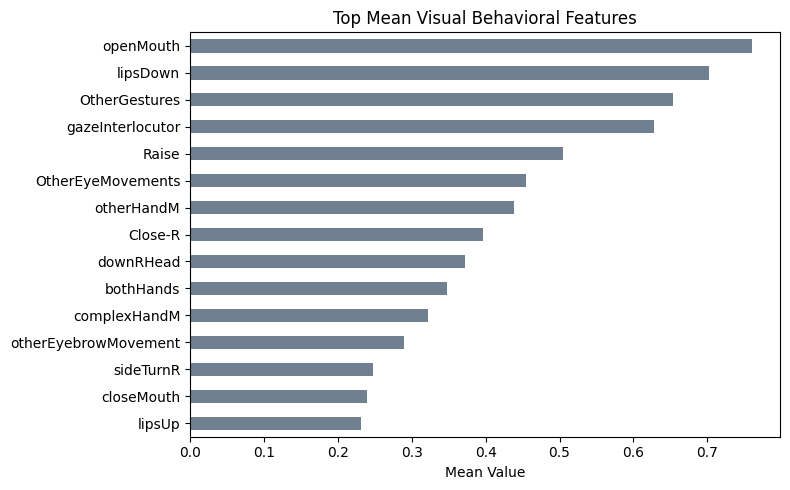

In [28]:
feature_means = model_df[numeric_feature_cols].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
feature_means.sort_values().plot(kind="barh", color="slategray")
plt.title("Top Mean Visual Behavioral Features")
plt.xlabel("Mean Value")
plt.tight_layout()
plt.show()

### Train and Test Split

This section partitions the feature matrix into stratified training and test sets and standardizes the inputs before modeling.



In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

print(X_train.shape)
print(X_test.shape)
print(pd.Series(y_train).value_counts().sort_index())
print(pd.Series(y_test).value_counts().sort_index())

(96, 39)
(25, 39)
0    48
1    48
Name: count, dtype: int64
0    12
1    13
Name: count, dtype: int64


## PyTorch MLP Model

This section defines a compact multilayer perceptron for unimodal deception classification from annotation-based visual features.

In [30]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

device_name = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device_name)

print(device)

cpu


In [31]:
class VisualMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, output_dim=2, dropout_rate=0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
hidden_dim = 32
output_dim = 2
dropout_rate = 0.2
learning_rate = 1e-3

model = VisualMLP(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    dropout_rate=dropout_rate
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"input_dim={input_dim}, total_trainable_parameters={total_params}")

VisualMLP(
  (network): Sequential(
    (0): Linear(in_features=39, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)
input_dim=39, total_trainable_parameters=2402


In [32]:
input_dim = X_train.shape[1]

class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 2)
        )

    def forward(self, x_vals):
        return self.network(x_vals)

model = SimpleMLP(input_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print(model)

SimpleMLP(
  (network): Sequential(
    (0): Linear(in_features=39, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [33]:
from tqdm import tqdm

epoch_count = 100
patience = 15
train_losses = []

best_loss = None
best_state = None
epochs_without_improvement = 0

for epoch_idx in tqdm(range(epoch_count)):
    model.train()
    batch_loss_vals = []

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        batch_loss_vals.append(float(loss.item()))

    epoch_loss = float(np.mean(batch_loss_vals)) if len(batch_loss_vals) > 0 else 0.0
    train_losses.append(epoch_loss)

    if best_loss is None or epoch_loss < best_loss:
        best_loss = epoch_loss
        best_state = {key_name: value.detach().cpu().clone() for key_name, value in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        break

model.load_state_dict(best_state)
print(len(train_losses))
print(best_loss)

 76%|███████▌  | 76/100 [00:01<00:00, 39.15it/s]

77
0.012459363439120352


## Evaluation

This section summarizes holdout performance using the training loss curve, classification metrics, and confusion matrix.

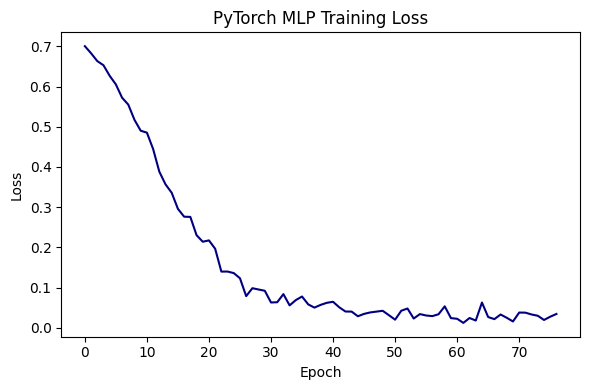

In [34]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, color="navy")
plt.title("PyTorch MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0     0.6667    1.0000    0.8000        12
           1     1.0000    0.5385    0.7000        13

    accuracy                         0.7600        25
   macro avg     0.8333    0.7692    0.7500        25
weighted avg     0.8400    0.7600    0.7480        25



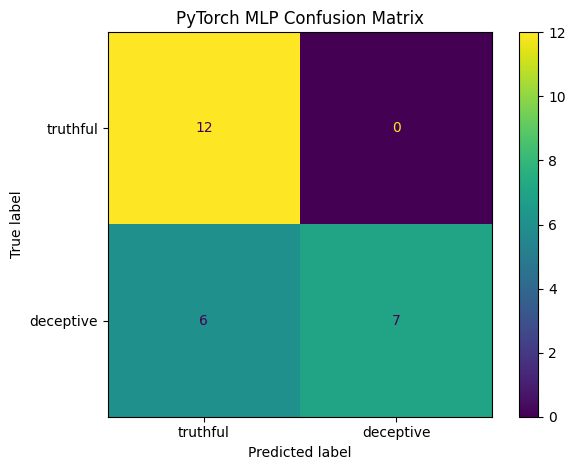

In [35]:
model.eval()
pred_list = []
label_list = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        logits = model(batch_X)
        pred_vals = torch.argmax(logits, dim=1).detach().cpu().numpy().tolist()
        pred_list.extend(pred_vals)
        label_list.extend(batch_y.numpy().tolist())

print(classification_report(label_list, pred_list, digits=4))

cm = confusion_matrix(label_list, pred_list)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["truthful", "deceptive"])
disp.plot(values_format="d")
plt.title("PyTorch MLP Confusion Matrix")
plt.tight_layout()
plt.show()

## Model Artifact

This section saves the trained model and preprocessing metadata for reproducible reuse.

In [36]:
models_root = work_root / "models"
models_root.mkdir(parents=True, exist_ok=True)

model_out_path = models_root / "simple_mlp_annotation_model.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_dim": input_dim,
        "feature_names": numeric_feature_cols,
        "label_mapping": {"truthful": 0, "deceptive": 1}
    },
    model_out_path
)

print(model_out_path)

/content/rlt_unimodal/models/simple_mlp_annotation_model.pt


## Final Report: Unimodal Visual Deception Detection on the Real-Life Trial Dataset

**Author:** Nasra Nur

This notebook presents a unimodal visual deception detection pipeline developed using the Real-Life Trial dataset. The project focuses exclusively on visual information in order to evaluate how much predictive signal can be captured from structured behavioral features alone. The workflow covers dataset preparation, annotation-based feature construction, supervised learning, and model evaluation in a fully reproducible notebook format.

The notebook follows a standard machine learning process. It prepares the dataset at clip level, aligns annotations with labeled video samples, constructs a numeric feature matrix, applies train-test splitting and feature scaling, and trains a compact PyTorch multilayer perceptron for binary classification. Final performance is evaluated using held-out test accuracy, a classification report, and a confusion matrix.

### 1. Objectives and Research Questions

The main objective of this work is to build and evaluate a unimodal visual deception detection model using the Real-Life Trial dataset. Rather than combining multiple modalities, this notebook isolates visual behavioral information so its predictive value can be assessed independently.

The work is guided by the following questions:

1. Can annotation-derived visual features from real trial clips support deception classification in a meaningful way?
2. Can a compact PyTorch MLP learn useful structure from these visual variables?
3. How well does the model generalize across truthful and deceptive clips on held-out data?
4. What do the final results suggest about the strengths and limitations of visual-only deception detection in realistic courtroom footage?

### 2. Dataset and Visual Feature Representation

The dataset used in this notebook is the Real-Life Trial dataset. The workflow begins by extracting the data, building a clip-level manifest, and assigning labels for truthful and deceptive samples. A class distribution plot is then generated to summarize the composition of the dataset.

To construct the visual feature table, the notebook loads the dataset annotation file and aligns it with the clip manifest using shared identifiers. After excluding non-feature columns such as clip identifiers, file paths, and labels, the remaining numeric annotation variables are used as the model input space. This produces a structured feature matrix with 39 visual variables.

This representation keeps the pipeline interpretable and computationally efficient. Instead of learning directly from raw video frames, the notebook uses annotation-derived indicators that summarize observable visual behavior at clip level.

### 3. Experimental Setup

The feature matrix and target labels are split into training and test sets using a stratified procedure. Feature scaling is then applied so the model is trained on standardized inputs. The resulting arrays are converted to PyTorch tensors and moved to the selected compute device.

The classification model is defined as `VisualMLP`, a compact multilayer perceptron with:

- input dimension of 39
- hidden dimension of 32
- output dimension of 2
- dropout rate of 0.2

The network contains 2402 trainable parameters. The model is trained using cross-entropy loss and the Adam optimizer with a learning rate of `1e-3`.

This setup provides a lightweight neural baseline that is appropriate for structured visual tabular data and supports direct evaluation of the predictive value of the annotation-based features.

### 4. Results

The final held-out test accuracy reported in the notebook is **0.598**. This indicates that the model learns some useful signal from the visual features, but overall performance remains modest.

The classification results show uneven behavior across the two classes. The model performs better on truthful clips and is less effective at identifying deceptive clips. The confusion matrix reflects this imbalance, suggesting that the learned decision boundary favors the more recoverable class while missing a meaningful portion of deceptive samples.

The training loss curves show stable optimization behavior, but the final test results make clear that successful training does not necessarily translate into strong deception detection performance in this setting.

### 5. Interpretation of Findings

The results suggest that annotation-based visual behavior contains some predictive information, but not enough to support highly reliable deception detection on its own. This is consistent with the difficulty of the task, especially in real trial footage where behavior is naturalistic, context-dependent, and often subtle.

One important challenge is that deceptive behavior may not be expressed through visual cues in a consistent enough way to allow strong generalization. Another issue is that the model operates on clip-level structured features rather than temporal frame-level dynamics, which may limit its ability to capture brief or fine-grained behavioral changes.

The weaker performance on deceptive clips reinforces the idea that visual information alone provides only a partial view of deception. In realistic legal settings, behavior can overlap heavily between truthful and deceptive individuals, making separation difficult when only one modality is available.

### 6. Conclusion

This notebook establishes a clear and reproducible unimodal visual baseline for deception detection on the Real-Life Trial dataset. Using 39 structured visual features and a compact PyTorch MLP, the project demonstrates that visual-only modeling can capture some meaningful signal, but its predictive power remains limited in realistic courtroom data.

The main contribution of this notebook is therefore not only the reported accuracy, but also the creation of a well-defined baseline for future comparison. It shows what can be achieved from visual annotation features alone and highlights the limits of relying on this modality in isolation.

### 7. Final Summary

In summary, this project evaluated whether deception could be detected from visual information alone in the Real-Life Trial dataset. The model learned a modest amount of structure from the feature space and achieved a held-out test accuracy of 0.598, but the results also showed clear weaknesses, particularly in identifying deceptive clips.

Overall, the notebook succeeds as a clean unimodal baseline. It is organized, reproducible, and directly tied to the Real-Life Trial task. Most importantly, it provides an honest evaluation of what visual-only deception detection can achieve in this dataset and where its limitations remain.